In [2]:
# ── Cell 1 — Setup ( ───────────────────────────────────────────────
import pandas as pd
import numpy as np
import os
import json
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_auc_score, average_precision_score
import matplotlib.pyplot as plt
import seaborn as sns

print(f'PyTorch version : {torch.__version__}')
print(f'CUDA available  : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU             : {torch.cuda.get_device_name(0)}')
    print(f'VRAM            : '
          f'{torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device    : {device}')

# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_DIR   = '/workspace'
MODELS_DIR = '/workspace/models'
os.makedirs(MODELS_DIR, exist_ok=True)

# ── Load data ─────────────────────────────────────────────────────────────────
print('\nLoading features...')

train = pd.read_csv(os.path.join(DATA_DIR, 'features_train.csv.gz'))
val   = pd.read_csv(os.path.join(DATA_DIR, 'features_val.csv.gz'))
test  = pd.read_csv(os.path.join(DATA_DIR, 'features_test.csv.gz'))

print(f'  Train : {len(train):,} rows × {train.shape[1]} columns')
print(f'  Val   : {len(val):,} rows × {val.shape[1]} columns')
print(f'  Test  : {len(test):,} rows × {test.shape[1]} columns')

# ── Feature columns ───────────────────────────────────────────────────────────
feature_cols = [
    'heart_rate', 'sbp', 'dbp', 'map',
    'resp_rate', 'temperature', 'spo2',
    'creatinine', 'platelets', 'bilirubin',
    'lactate', 'hemoglobin', 'wbc',
    'glucose', 'potassium', 'sodium',
    'sofa_resp', 'sofa_coag', 'sofa_liver',
    'sofa_cardio', 'sofa_neuro', 'sofa_renal',
    'hours_from_admission',
]

target_col  = 'deterioration'
MAX_SEQ_LEN = 168  # ← full week, covers 85.6% of patients
BATCH_SIZE  = 512  # ← A40 48GB can handle this easily

print(f'\nFeature count   : {len(feature_cols)}')
print(f'Sequence length : {MAX_SEQ_LEN} hours (7 days)')
print(f'Batch size      : {BATCH_SIZE}')

PyTorch version : 2.4.1+cu124
CUDA available  : True
GPU             : NVIDIA A40
VRAM            : 47.7 GB
Using device    : cuda

Loading features...
  Train : 3,805,715 rows × 26 columns
  Val   : 821,839 rows × 26 columns
  Test  : 806,012 rows × 26 columns

Feature count   : 23
Sequence length : 168 hours (7 days)
Batch size      : 512


In [3]:
# ── Cell 2 — Build Patient Sequences ─────────────────────────────────────────
print('Building patient sequences...')

def build_sequences(df, feature_cols, target_col, max_len=MAX_SEQ_LEN):

    sequences = []
    labels    = []
    stay_ids  = []

    df = df.sort_values(['stay_id', 'hours_from_admission'])

    grouped = df.groupby('stay_id')

    for stay_id, group in grouped:

        X = group[feature_cols].values.astype(np.float32)
        y = group[target_col].iloc[0]

        # Truncate → keep last 168 hours
        if len(X) > max_len:
            X = X[-max_len:]

        # Pad → pad start with zeros
        elif len(X) < max_len:
            pad_len = max_len - len(X)
            padding = np.zeros((pad_len, len(feature_cols)),
                               dtype=np.float32)
            X = np.vstack([padding, X])

        sequences.append(X)
        labels.append(y)
        stay_ids.append(stay_id)

    sequences = np.array(sequences, dtype=np.float32)
    labels    = np.array(labels,    dtype=np.float32)

    return sequences, labels, stay_ids

print('  Processing train...')
X_train, y_train, train_ids = build_sequences(
    train, feature_cols, target_col
)
print(f'  Train : {X_train.shape}')

print('  Processing val...')
X_val, y_val, val_ids = build_sequences(
    val, feature_cols, target_col
)
print(f'  Val   : {X_val.shape}')

print('  Processing test...')
X_test, y_test, test_ids = build_sequences(
    test, feature_cols, target_col
)
print(f'  Test  : {X_test.shape}')

print(f'\nLabel distribution (train):')
print(f'  Positive : {y_train.sum():,.0f} ({y_train.mean()*100:.1f}%)')
print(f'  Negative : {(1-y_train).sum():,.0f} '
      f'({(1-y_train).mean()*100:.1f}%)')

# ── Memory estimate ───────────────────────────────────────────────────────────
mem_gb = X_train.nbytes / 1e9
print(f'\nTrain array size : {mem_gb:.2f} GB in RAM')

# ── PyTorch Dataset + DataLoader ──────────────────────────────────────────────
class ICUSequenceDataset(Dataset):
    def __init__(self, sequences, labels):
        self.X = torch.tensor(sequences, dtype=torch.float32)
        self.y = torch.tensor(labels,    dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = ICUSequenceDataset(X_train, y_train)
val_dataset   = ICUSequenceDataset(X_val,   y_val)
test_dataset  = ICUSequenceDataset(X_test,  y_test)

train_loader = DataLoader(
    train_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = True,
    num_workers = 4,      
    pin_memory  = True
)
val_loader = DataLoader(
    val_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = False,
    num_workers = 4,
    pin_memory  = True
)
test_loader = DataLoader(
    test_dataset,
    batch_size  = BATCH_SIZE,
    shuffle     = False,
    num_workers = 4,
    pin_memory  = True
)

print(f'\nBatch size     : {BATCH_SIZE}')
print(f'Train batches  : {len(train_loader):,}')
print(f'Val batches    : {len(val_loader):,}')
print(f'Test batches   : {len(test_loader):,}')

X_batch, y_batch = next(iter(train_loader))
print(f'\nSample batch:')
print(f'  X : {X_batch.shape}')
print(f'  y : {y_batch.shape}')


Building patient sequences...
  Processing train...
  Train : (36307, 168, 23)
  Processing val...
  Val   : (7756, 168, 23)
  Processing test...
  Test  : (7776, 168, 23)

Label distribution (train):
  Positive : 9,876 (27.2%)
  Negative : 26,431 (72.8%)

Train array size : 0.56 GB in RAM

Batch size     : 512
Train batches  : 71
Val batches    : 16
Test batches   : 16

Sample batch:
  X : torch.Size([512, 168, 23])
  y : torch.Size([512])


In [4]:
# ── Cell 3 — TECO Architecture (A40 Optimised) ───────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F

class TemporalBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size,
                 dilation, dropout=0.3):
        super(TemporalBlock, self).__init__()

        padding = (kernel_size - 1) * dilation

        self.conv1 = nn.Conv1d(
            in_channels, out_channels, kernel_size,
            dilation=dilation, padding=padding
        )
        self.conv2 = nn.Conv1d(
            out_channels, out_channels, kernel_size,
            dilation=dilation, padding=padding
        )

        self.bn1     = nn.BatchNorm1d(out_channels)
        self.bn2     = nn.BatchNorm1d(out_channels)
        self.dropout = nn.Dropout(dropout)
        self.relu    = nn.ReLU()

        self.residual = (
            nn.Conv1d(in_channels, out_channels, 1)
            if in_channels != out_channels else nn.Identity()
        )

    def forward(self, x):
        residual = self.residual(x)

        out = self.conv1(x)
        out = out[:, :, :-self.conv1.padding[0]]
        out = self.bn1(out)
        out = self.relu(out)
        out = self.dropout(out)

        out = self.conv2(out)
        out = out[:, :, :-self.conv2.padding[0]]
        out = self.bn2(out)
        out = self.relu(out)
        out = self.dropout(out)

        return self.relu(out + residual)


class TECOModel(nn.Module):
    def __init__(self,
                 input_size,
                 num_channels = [64, 128, 256, 512],  # ← deeper for A40
                 kernel_size  = 3,
                 dropout      = 0.3,
                 num_heads    = 8):
        super(TECOModel, self).__init__()

        # ── 1. Input projection ───────────────────────────────────────────────
        self.input_proj = nn.Linear(input_size, num_channels[0])

        # ── 2. Temporal convolutional blocks ──────────────────────────────────
        # 4 blocks with increasing dilation
        # dilation 1,2,4,8 → captures patterns up to 168 hours
        layers = []
        for i in range(len(num_channels)):
            in_ch  = num_channels[i-1] if i > 0 else num_channels[0]
            out_ch = num_channels[i]
            layers.append(
                TemporalBlock(
                    in_ch, out_ch,
                    kernel_size = kernel_size,
                    dilation    = 2 ** i,
                    dropout     = dropout
                )
            )
        self.tcn = nn.Sequential(*layers)

        # ── 3. Multi-head attention ───────────────────────────────────────────
        self.attention = nn.MultiheadAttention(
            embed_dim   = num_channels[-1],
            num_heads   = num_heads,
            dropout     = dropout,
            batch_first = True
        )
        self.attn_norm = nn.LayerNorm(num_channels[-1])

        # ── 4. Classifier head ────────────────────────────────────────────────
        self.classifier = nn.Sequential(
            nn.Linear(num_channels[-1], 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1),
        )

    def forward(self, x):
        # x → (batch, seq_len, input_size)
        x = self.input_proj(x)
        x = x.transpose(1, 2)
        x = self.tcn(x)
        x = x.transpose(1, 2)
        attn_out, _ = self.attention(x, x, x)
        x = self.attn_norm(x + attn_out)
        x = x.mean(dim=1)
        out = self.classifier(x)
        return out.squeeze(1)


# ── Instantiate model ─────────────────────────────────────────────────────────
model_teco = TECOModel(
    input_size   = len(feature_cols),
    num_channels = [64, 128, 256, 512],  # ← 4 blocks vs 3 before
    kernel_size  = 3,
    dropout      = 0.3,
    num_heads    = 8
).to(device)

total_params = sum(p.numel() for p in model_teco.parameters())
trainable    = sum(p.numel() for p in model_teco.parameters()
                   if p.requires_grad)

print('TECO Architecture (A40 Optimised):')
print(model_teco)
print(f'\nTotal parameters    : {total_params:,}')
print(f'Trainable parameters: {trainable:,}')
print(f'Device              : {device}')

# ── Loss and optimizer ────────────────────────────────────────────────────────
pos_weight = torch.tensor(
    [(y_train == 0).sum() / (y_train == 1).sum()],
    dtype=torch.float32
).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = torch.optim.Adam(
    model_teco.parameters(),
    lr           = 0.001,
    weight_decay = 1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode     = 'max',
    factor   = 0.5,
    patience = 3,
    verbose  = True
)

print(f'\nLoss        : BCEWithLogitsLoss '
      f'(pos_weight={pos_weight.item():.4f})')
print(f'Optimizer   : Adam (lr=0.001, weight_decay=1e-4)')
print(f'Scheduler   : ReduceLROnPlateau (patience=3)')
print(f'Dropout     : 0.3')
print(f'Sequence    : {MAX_SEQ_LEN} hours')
print(f'Batch size  : {BATCH_SIZE}')

TECO Architecture (A40 Optimised):
TECOModel(
  (input_proj): Linear(in_features=23, out_features=64, bias=True)
  (tcn): Sequential(
    (0): TemporalBlock(
      (conv1): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(2,))
      (conv2): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(2,))
      (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (dropout): Dropout(p=0.3, inplace=False)
      (relu): ReLU()
      (residual): Identity()
    )
    (1): TemporalBlock(
      (conv1): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(2,))
      (conv2): Conv1d(128, 128, kernel_size=(3,), stride=(1,), padding=(4,), dilation=(2,))
      (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (bn2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (d

In [5]:
# ── Cell 4 — Train TECO (A40 Optimised) ──────────────────────────────────────
import time

EPOCHS        = 50
PATIENCE      = 7
best_auroc    = 0.0
best_epoch    = 0
epochs_no_imp = 0
history       = {'train_loss': [], 'val_loss': [], 'val_auroc': []}

print('=' * 60)
print('TECO TRAINING — A40 48GB')
print('=' * 60)
print(f'Epochs          : {EPOCHS}')
print(f'Early stopping  : {PATIENCE} epochs patience')
print(f'Batch size      : {BATCH_SIZE}')
print(f'Sequence length : {MAX_SEQ_LEN} hours')
print(f'Device          : {device}')
print('=' * 60)

for epoch in range(1, EPOCHS + 1):
    epoch_start = time.time()

    # ── Training phase ────────────────────────────────────────────────────────
    model_teco.train()
    train_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()
        preds = model_teco(X_batch)
        loss  = criterion(preds, y_batch)
        loss.backward()

        nn.utils.clip_grad_norm_(model_teco.parameters(), max_norm=1.0)

        optimizer.step()
        train_loss += loss.item()

    train_loss /= len(train_loader)

    # ── Validation phase ──────────────────────────────────────────────────────
    model_teco.eval()
    val_loss   = 0.0
    val_preds  = []
    val_labels = []

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            preds    = model_teco(X_batch)
            loss     = criterion(preds, y_batch)
            val_loss += loss.item()

            val_preds.extend(preds.cpu().numpy())
            val_labels.extend(y_batch.cpu().numpy())

    val_loss  /= len(val_loader)
    val_auroc  = roc_auc_score(val_labels, val_preds)

    scheduler.step(val_auroc)

    # ── Save best + early stopping ────────────────────────────────────────────
    if val_auroc > best_auroc:
        best_auroc    = val_auroc
        best_epoch    = epoch
        epochs_no_imp = 0
        torch.save(
            model_teco.state_dict(),
            os.path.join(MODELS_DIR, 'teco_best.pt')
        )
    else:
        epochs_no_imp += 1
        if epochs_no_imp >= PATIENCE:
            print(f'\nEarly stopping at epoch {epoch}')
            print(f'No improvement for {PATIENCE} epochs')
            break

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['val_auroc'].append(val_auroc)

    epoch_time = time.time() - epoch_start

    print(f'Epoch {epoch:02d}/{EPOCHS} '
          f'| Train Loss: {train_loss:.4f} '
          f'| Val Loss: {val_loss:.4f} '
          f'| Val AUROC: {val_auroc:.4f} '
          f'| Time: {epoch_time:.1f}s '
          f'{"← best" if epoch == best_epoch else f"(no imp {epochs_no_imp}/{PATIENCE})"}')

print('\n' + '=' * 60)
print(f'Training complete!')
print(f'Best AUROC : {best_auroc:.4f} at epoch {best_epoch}')
print('=' * 60)

TECO TRAINING — A40 48GB
Epochs          : 50
Early stopping  : 7 epochs patience
Batch size      : 512
Sequence length : 168 hours
Device          : cuda
Epoch 01/50 | Train Loss: 0.7604 | Val Loss: 0.8080 | Val AUROC: 0.8371 | Time: 14.2s ← best
Epoch 02/50 | Train Loss: 0.6837 | Val Loss: 0.7060 | Val AUROC: 0.8558 | Time: 13.4s ← best
Epoch 03/50 | Train Loss: 0.6555 | Val Loss: 0.6889 | Val AUROC: 0.8636 | Time: 13.4s ← best
Epoch 04/50 | Train Loss: 0.6366 | Val Loss: 0.6776 | Val AUROC: 0.8721 | Time: 13.5s ← best
Epoch 05/50 | Train Loss: 0.6255 | Val Loss: 0.6834 | Val AUROC: 0.8793 | Time: 13.5s ← best
Epoch 06/50 | Train Loss: 0.6172 | Val Loss: 0.7002 | Val AUROC: 0.8691 | Time: 13.3s (no imp 1/7)
Epoch 07/50 | Train Loss: 0.6055 | Val Loss: 0.7369 | Val AUROC: 0.8757 | Time: 13.5s (no imp 2/7)
Epoch 08/50 | Train Loss: 0.6081 | Val Loss: 0.7074 | Val AUROC: 0.8778 | Time: 13.4s (no imp 3/7)
Epoch 09/50 | Train Loss: 0.5878 | Val Loss: 0.6586 | Val AUROC: 0.8833 | Time: 13.

TECO TEST SET PERFORMANCE

AUROC : 0.9206
AUPRC : 0.8208

Classification Report:
               precision    recall  f1-score   support

       Stable       0.91      0.90      0.90      5661
Deterioration       0.74      0.75      0.75      2115

     accuracy                           0.86      7776
    macro avg       0.83      0.83      0.83      7776
 weighted avg       0.86      0.86      0.86      7776



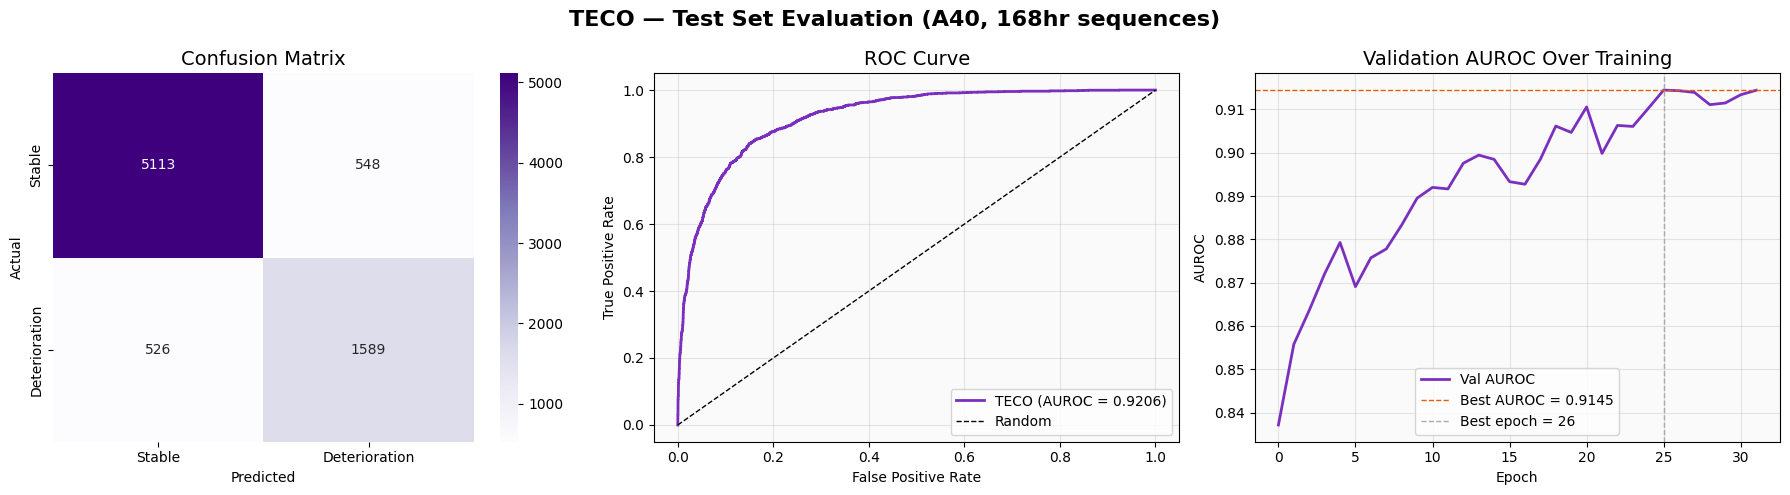


✅ TECO evaluation complete!
   AUROC (val)  : 0.9145
   AUROC (test) : 0.9206
   AUPRC (test) : 0.8208



In [11]:
# ── Cell 5 — Evaluate TECO on Test Set ───────────────────────────────────────
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    classification_report, confusion_matrix, roc_curve
)
import matplotlib.pyplot as plt
import seaborn as sns
import json

# Load best model
model_teco.load_state_dict(
    torch.load(os.path.join(MODELS_DIR, 'teco_best.pt'))
)
model_teco.eval()

test_preds  = []
test_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        preds   = model_teco(X_batch)
        test_preds.extend(preds.cpu().numpy())
        test_labels.extend(y_batch.numpy())

auroc             = roc_auc_score(test_labels, test_preds)
auprc             = average_precision_score(test_labels, test_preds)
test_preds_binary = [1 if p > 0.5 else 0 for p in test_preds]

print('=' * 50)
print('TECO TEST SET PERFORMANCE')
print('=' * 50)
print(f'\nAUROC : {auroc:.4f}')
print(f'AUPRC : {auprc:.4f}')
print(f'\nClassification Report:')
print(classification_report(
    test_labels, test_preds_binary,
    target_names=['Stable', 'Deterioration']
))

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1 — Confusion matrix → purple palette
cm = confusion_matrix(test_labels, test_preds_binary)
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Purples',
    xticklabels=['Stable', 'Deterioration'],
    yticklabels=['Stable', 'Deterioration'],
    ax=axes[0]
)
axes[0].set_title('Confusion Matrix', fontsize=14)
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Plot 2 — ROC Curve → purple line
fpr, tpr, _ = roc_curve(test_labels, test_preds)
axes[1].plot(fpr, tpr, color='#7B2FBE', lw=2,
             label=f'TECO (AUROC = {auroc:.4f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontsize=14)
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_facecolor('#FAFAFA')

# Plot 3 — Training history → purple line
axes[2].plot(history['val_auroc'], color='#7B2FBE', lw=2,
             label='Val AUROC')
axes[2].axhline(y=best_auroc, color='#E85D04', linestyle='--',
                lw=1, label=f'Best AUROC = {best_auroc:.4f}')
axes[2].axvline(x=best_epoch - 1, color='#AAAAAA', linestyle='--',
                lw=1, label=f'Best epoch = {best_epoch}')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('AUROC')
axes[2].set_title('Validation AUROC Over Training', fontsize=14)
axes[2].legend()
axes[2].grid(True, alpha=0.3)
axes[2].set_facecolor('#FAFAFA')

plt.suptitle('TECO — Test Set Evaluation (A40, 168hr sequences)',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('/workspace/teco_results.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Save results ──────────────────────────────────────────────────────────────
results = {
    'model'       : 'TECO',
    'seq_length'  : MAX_SEQ_LEN,
    'batch_size'  : BATCH_SIZE,
    'best_epoch'  : best_epoch,
    'auroc_val'   : round(best_auroc, 4),
    'auroc_test'  : round(auroc, 4),
    'auprc_test'  : round(auprc, 4),
}
with open('/workspace/teco_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print(f'\n✅ TECO evaluation complete!')
print(f'   AUROC (val)  : {best_auroc:.4f}')
print(f'   AUROC (test) : {auroc:.4f}')
print(f'   AUPRC (test) : {auprc:.4f}')
print(f'\n{"=" * 50}')

In [12]:
import os
import json

print('Files in /workspace:')
for f in os.listdir('/workspace'):
    fpath = os.path.join('/workspace', f)
    if os.path.isfile(fpath):
        size = os.path.getsize(fpath) / (1024 * 1024)
        print(f'  {f:40s} → {size:.1f} MB')

print('\nTECO results:')
with open('/workspace/teco_results.json', 'r') as f:
    print(json.dumps(json.load(f), indent=2))

Files in /workspace:
  vitalwatch_comparison.png                → 0.1 MB
  teco_results.json                        → 0.0 MB
  teco_results.png                         → 0.2 MB
  05_teco_runpod.ipynb                     → 0.2 MB
  features_train.csv.gz                    → 60.5 MB
  features_test.csv.gz                     → 12.8 MB
  features_val.csv.gz                      → 13.0 MB

TECO results:
{
  "model": "TECO",
  "seq_length": 168,
  "batch_size": 512,
  "best_epoch": 26,
  "auroc_val": 0.9145,
  "auroc_test": 0.9206,
  "auprc_test": 0.8208
}
